In [1]:
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
# Open a cube with specific spanshot number:
cube = fits.open("/dat/milic/3D/3D_snapi_spectra/tumag_stokesIV_cube_0.fits")[0].data

# Note: all the data is in:
# /dat/milic/3D/3D_snapi_spectra/ 
# in fits format. 
# which should be accessible

NameError: name 'pyana' is not defined

In [3]:
cube.shape
# Indices are x,y, stokes component, wavelength

(768, 768, 2, 622)

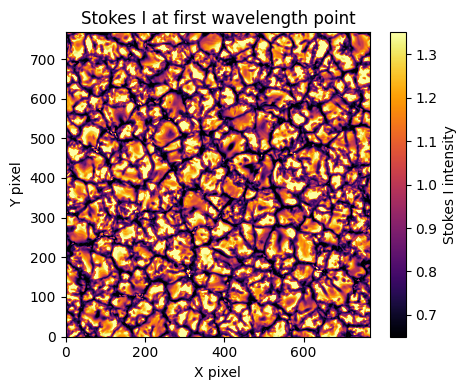

In [6]:
# Plot image at a specific wavelength: 
plt.figure(figsize=(5,4))
plt.imshow(cube[:,:,0,0].T, origin='lower', cmap='inferno', vmin=0.65, vmax=1.35)
plt.colorbar(label='Stokes I intensity')
plt.title('Stokes I at first wavelength point')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')
plt.tight_layout()

In [7]:
# As always we will normalize the units for the intensity to something we have a better physical intuition about.
# In this case fits cubes are already normalized to the continuum intensity, so we will not do anything further.

In [ ]:
# Now we want to make an image like the one up there, but with a slider that allows us to change the wavelength position interactively.
from ipywidgets import interact, IntSlider
@interact(wavelength_index=IntSlider(min=0, max=cube.shape[3]-1, step=1, value=0))
def plot_stokesI_at_wavelength(wavelength_index):
    plt.figure(figsize=(5,4))
    plt.imshow(cube[:,:,0,wavelength_index].T, origin='lower', cmap='inferno')
    plt.colorbar(label='Stokes I intensity (in units of I_qs)')
    plt.title(f'Stokes I at wavelength index {wavelength_index}')
    plt.xlabel('X pixel')
    plt.ylabel('Y pixel')
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=0, description='wavelength_index', max=621), Output()), _dom_classes=('w…

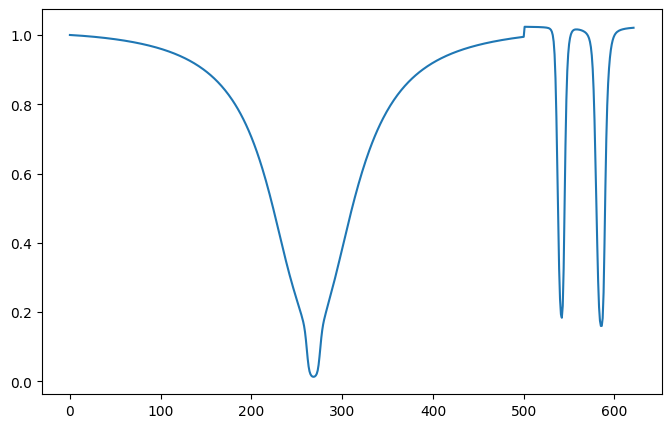

In [10]:
# to find interesting wavelength positions, we can plot the average spectrum over the whole cube:
mean_spectrum = np.mean(cube[:,:,0,:], axis=(0,1))
plt.figure(figsize=(8,5))
plt.plot(mean_spectrum)

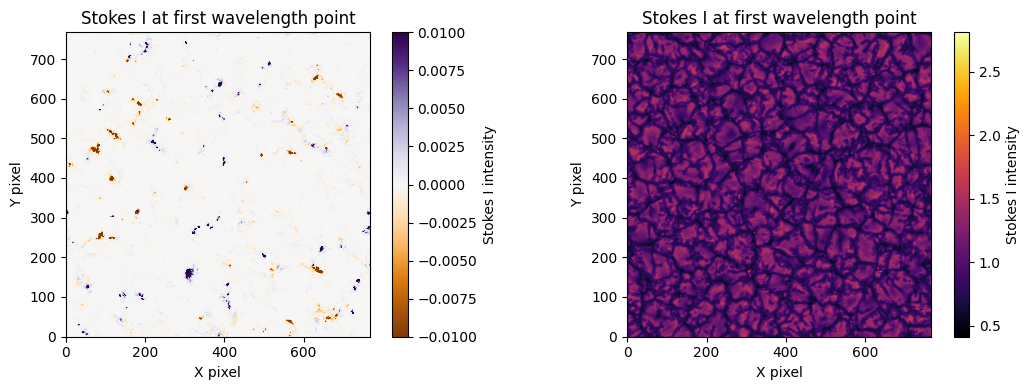

In [14]:
# Plot image at a specific wavelength: 
plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
#plt.imshow(cube[:,:,3,265].T, origin='lower', cmap='inferno',vmin=0.0,vmax=0.3)
plt.imshow(cube[:,:,1,265].T, origin='lower', cmap='PuOr',vmin=-0.01,vmax=0.01)
plt.colorbar(label='Stokes I intensity')
plt.title('Stokes I at first wavelength point')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')
plt.subplot(1,2,2)
plt.imshow(cube[:,:,0,0].T, origin='lower', cmap='inferno')
plt.colorbar(label='Stokes I intensity')
plt.title('Stokes I at first wavelength point')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')
plt.tight_layout()

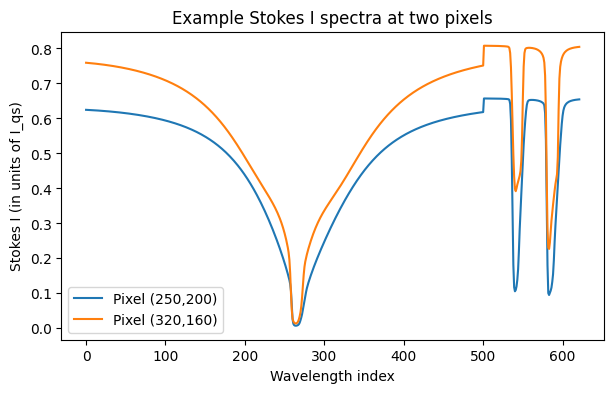

In [16]:
# Let's plot two example spectra:
plt.figure(figsize=(7,4))
plt.plot(cube[250,200,0,:], label='Pixel (250,200)')
plt.plot(cube[320,160,0,:], label='Pixel (320,160)')
plt.xlabel('Wavelength index')
plt.ylabel('Stokes I (in units of I_qs)')
plt.title('Example Stokes I spectra at two pixels')
plt.legend()

In [31]:
import muram as mio 
# here we want to read the old muram format files directly to get the velocity cubes and compare to what we see here
# We are taking tau = - 1 here because we found earlier that one works the best.
murampath = '/dat/milic/2D'

muramslice = mio.MuramTauSlice(murampath,0,0.100)

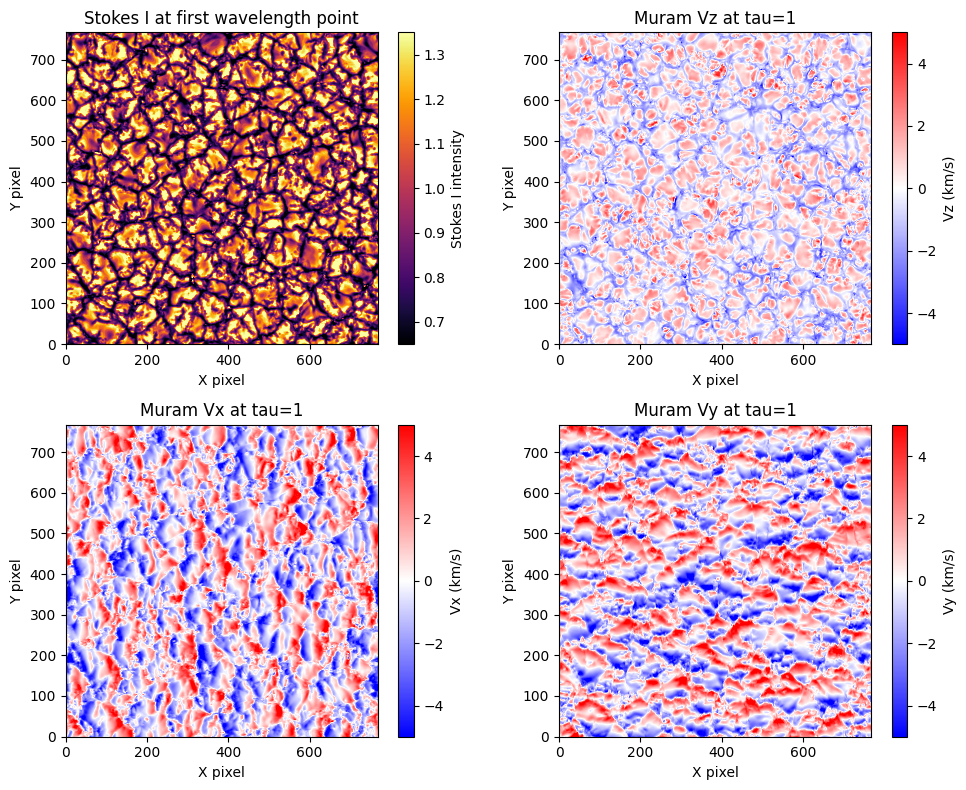

In [32]:
# Now we want to compare our image with the velocity map from muram at tau=1
# Make it a 2x2 subplots, so that we can have intensity, vx, vy, vz
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
plt.imshow(cube[:,:,0,0].T, origin='lower', cmap='inferno', vmin=0.65, vmax=1.35)
plt.colorbar(label='Stokes I intensity')
plt.title('Stokes I at first wavelength point')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')
plt.subplot(2,2,2)
plt.imshow(muramslice.vx[::2,::2].T/1E5, origin='lower', cmap='bwr', vmin=-5, vmax=5)
plt.colorbar(label='Vz (km/s)')
plt.title('Muram Vz at tau=1')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')

plt.subplot(2,2,4)
plt.imshow(muramslice.vz[::2,::2].T/1E5, origin='lower', cmap='bwr', vmin=-5, vmax=5)
plt.colorbar(label='Vy (km/s)')
plt.title('Muram Vy at tau=1')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')
plt.subplot(2,2,3)
plt.imshow(muramslice.vy[::2,::2].T/1E5, origin='lower', cmap='bwr', vmin=-5, vmax=5)
plt.colorbar(label='Vx (km/s)')
plt.title('Muram Vx at tau=1')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')

plt.tight_layout()

In [ ]:
# So for the moment, we are only working with Stokes I 

# Once all the cubes are converted to fits, we can read them with astropy.io.fits

import pyana
from astropy.io import fits
for i in range(1350, 4650, 150):
    print (i)
    cube = pyana.fzread(f"/dat/milic/3D/3D_snapi_spectra/loc_dyn_32_32_16_{i}_tumag.f0")["data"]
    I_qs = np.mean(cube[:,:,0,:10])
    cube /= I_qs  # Now the intensity is in units of quiet sun intensity
    hdu = fits.PrimaryHDU(cube)
    hdu.writeto(f'/dat/milic/3D/3D_snapi_spectra/tumag_stokesIV_cube_{i}.fits', overwrite=True)
#cube = pyana.fzread("/dat/milic/3D/3D_snapi_spectra/loc_dyn_32_32_16_1200_tumag.f0")["data"]
#I_qs = np.mean(cube[:,:,0,:10])
#cube /= I_qs  # Now the intensity is in units of quiet sun intensity
#hdu = fits.PrimaryHDU(cube)
#hdu.writeto('/dat/milic/3D/3D_snapi_spectra/tumag_stokesIV_cube_1200.fits', overwrite=True)

1350
1500
1650
1800
1950
2100
2250
2400
